In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as grd
from accuracy import *
from data_cuts import *
import mpl_toolkits
import mpl_toolkits.axes_grid1 as axgrid
import matplotlib as mpl
import os
os.environ['PATH'] = os.environ['PATH'] + ':/home/kaad8904/texlive/2024/bin/x86_64-linux'
mpl.rcParams['text.usetex'] = True  # This forces use of system LaTeX
mpl.rcParams['font.family'] = 'serif'  # Use LaTeX serif fonts
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [2]:
Names = ["ID","M500c","f_gas_R500c","a_form","conc_200c","shape","Gamma_R500C"\
             ,"Gamma_vir","Log_T","Log_Z","OFe","NeFe","CO","axis placeholder"\
             ,"M500c_","M200c","f_gas_0.5R200c","f_gas_0.7R200c","f_gas_R200c","f_gas_2R200c"]
Dataset_overlord = pd.read_csv("/pl/active/CASA/beop5934/halos/TNG300/Params_Groups_TNG300_z=0.00.ascii_ID_fgas", delimiter = "\s+",names = Names)
DO_new = pd.DataFrame(np.repeat(Dataset_overlord.values,3,axis=0))
DO_new.columns = Dataset_overlord.columns
ids = DO_new['ID']
ids_new = []
for i in range(0,len(ids),3):
    ids_new.append(f"{int(ids[i])}_x")
    ids_new.append(f"{int(ids[i])}_y")
    ids_new.append(f"{int(ids[i])}_z")
DO_new["ID"] = ids_new    

Names_100 = ["ID","M200c","f_gas_R500c", "a_form","conc_200c","shape","Log_M_star","M500c",
                 "f_gas_0.5R200c","f_gas_0.7R200c","f_gas_R200c","f_gas_2R200c",
                 "Log_Z_50","Log_Z_100","Log_Z_200","OFe_50","OFe_100","OFe_200","f_cool_R500c"]
Dataset_overlord_100 = pd.read_csv("/pl/active/CASA/beop5934/halos/TNG100/Params_TNG100_z=0.00.multiradii.ascii_ID_fgas", delimiter = "\s+",names = Names_100)
DO_100_new = pd.DataFrame(np.repeat(Dataset_overlord_100.values,3,axis=0))
DO_100_new.columns = Dataset_overlord_100.columns
ids = DO_100_new['ID']
ids_new = []
for i in range(0,len(ids),3):
    ids_new.append(f"{int(ids[i])}_x")
    ids_new.append(f"{int(ids[i])}_y")
    ids_new.append(f"{int(ids[i])}_z")
DO_100_new["ID"] = ids_new

In [3]:
f = open('CNN_Light_Alpine_inputs.txt')
input_array = f.readlines()
output_array = []
n_empt_lin = 0
for i in range(len(input_array)):
    line = input_array[i].split()
    if(len(line) > 0):
        output_array.append(line)

In [4]:
# output_array

In [5]:
M500_TNG100_ticks = np.array([12,13,14])
M500_TNG100_lim = (11.3,14.2)

M500_TNG300_ticks = np.array([13,14])
M500_TNG300_lim = (12.7, 14.9)

f_gas_TNG100_ticks = np.array([0.033,0.095,0.157])
f_gas_TNG100_lim = (-0.012,0.17)

f_gas_TNG300_lim = (-0.005,0.17)
f_gas_TNG300_ticks = np.array([0.05,0.15])

f_cool_TNG100_ticks = np.array([0.17,0.55,0.92])
f_cool_TNG100_lim = (-0.1, 1.0)

# Plotting
### TNG100 M500 Fig 2

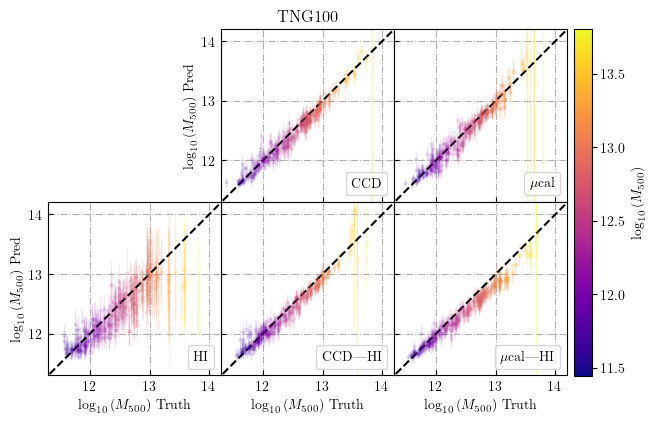

In [6]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "100"
grid1 = ["255","M500c"]
grid2 = ["257","M500c"]
grid3 = ["265","M500c"]
grid4 = ["267","M500c"]
grid5 = ["258","M500c"]
choice_array = [grid1,grid2,grid3,grid4,grid5]
plot_array = []

fig = plt.figure(figsize=(6.7,4.5))
gs = fig.add_gridspec(2,3,hspace=0,wspace=0)
later_axis = plt.gca()
later_axis.set_axis_off()
axtitle = fig.add_subplot(gs[0,0])
axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[1,2])
ax5 = fig.add_subplot(gs[1,0])
# axtitle.annotate("TNG100", (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3,ax4,ax5]
cm = plt.get_cmap("plasma")
if(sim == "100"):
    Master = np.array([DO_100_new["M500c"]])
elif(sim == "300"):
    Master = np.array([DO_new["M500c"]])
maxs = np.max(Master)
mins = np.min(Master)
window_range = (maxs-mins)*0.25/2
for i,choice in enumerate(choice_array):
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='plasma',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
#     title = f"TNG{sim}|"
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
    if(sim=="300"):
        ax.set_xticks(np.arange(12,15))
    elif(sim=="100"):
        ax.set_xticks(np.arange(12,15))
#     plt.tight_layout()
    ax.tick_params(direction='in')
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelleft=False,labelbottom=False)
ax3.tick_params(labelleft=False)
ax4.tick_params(labelleft=False)

ax1.set_xlim(M500_TNG100_lim)
ax1.set_ylim(M500_TNG100_lim)
ax1.xaxis.set_ticks(M500_TNG100_ticks)
ax1.yaxis.set_ticks(M500_TNG100_ticks)

ax2.set_xlim(M500_TNG100_lim)
ax2.set_ylim(M500_TNG100_lim)
ax2.xaxis.set_ticks(M500_TNG100_ticks)
ax2.yaxis.set_ticks(M500_TNG100_ticks)

ax3.set_xlim(M500_TNG100_lim)
ax3.set_ylim(M500_TNG100_lim)
ax3.xaxis.set_ticks(M500_TNG100_ticks)
ax3.yaxis.set_ticks(M500_TNG100_ticks)

ax4.set_xlim(M500_TNG100_lim)
ax4.set_ylim(M500_TNG100_lim)
ax4.xaxis.set_ticks(M500_TNG100_ticks)
ax4.yaxis.set_ticks(M500_TNG100_ticks)

ax5.set_xlim(M500_TNG100_lim)
ax5.set_ylim(M500_TNG100_lim)
ax5.xaxis.set_ticks(M500_TNG100_ticks)
ax5.yaxis.set_ticks(M500_TNG100_ticks)
#### Add axis titles
ax1.set_ylabel(r"$\log_{10}{(M_{500})}$ Pred")
ax5.set_ylabel(r"$\log_{10}{(M_{500})}$ Pred")
ax5.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax3.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax4.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax1.title.set_text("TNG100")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.4,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig2.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### TNG100 f_gas fig 3

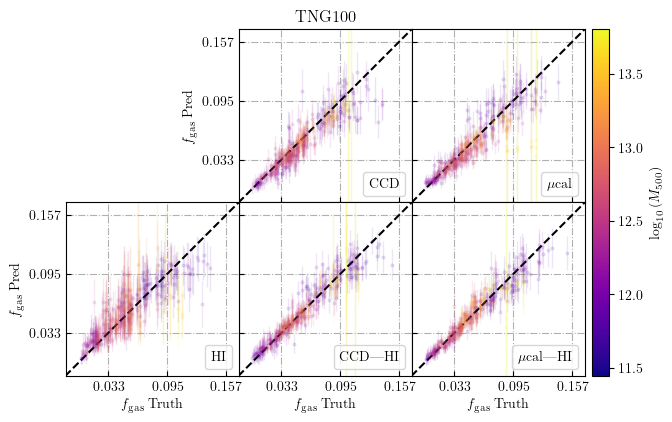

In [7]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "100"
grid1 = ["255","f_gas_R500c"]
grid2 = ["257","f_gas_R500c"]
grid3 = ["265","f_gas_R500c"]
grid4 = ["267","f_gas_R500c"]
grid5 = ["258","f_gas_R500c"]
choice_array = [grid1,grid2,grid3,grid4,grid5]
plot_array = []

fig = plt.figure(figsize=(6.7,4.5))
gs = fig.add_gridspec(2,3,hspace=0,wspace=0)
later_axis = plt.gca()
later_axis.set_axis_off()
axtitle = fig.add_subplot(gs[0,0])
axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[1,2])
ax5 = fig.add_subplot(gs[1,0])
# axtitle.annotate("TNG100", (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3,ax4,ax5]
cm = plt.get_cmap("plasma")
if(sim == "100"):
    Master = np.array([DO_100_new["f_gas_R500c"]])
elif(sim == "300"):
    Master = np.array([DO_new["f_gas_R500c"]])
maxs = np.max(Master)
mins = np.min(Master)
window_range = (maxs-mins)*0.25/2
for i,choice in enumerate(choice_array):
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
#     print("params = ",params)
#     print("choice = ",choice)
#     print("param_index = ",param_index)
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='plasma',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     print(mins,maxs,window_range,mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
#     ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
    ax.set_xticks(np.arange(0,0.2,0.1))
    ax.set_yticks(np.arange(0,0.2,0.1))
    ax.tick_params(direction='in')
#     if(sim=="300"):
#         ax.set_xticks(np.arange(12,15))
#     elif(sim=="100"):
#         ax.set_xticks(np.arange(12,15))
#     plt.tight_layout()
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelleft=False,labelbottom=False)
ax3.tick_params(labelleft=False)
ax4.tick_params(labelleft=False)

ax1.set_xlim(f_gas_TNG100_lim)
ax1.set_ylim(f_gas_TNG100_lim)
ax1.xaxis.set_ticks(f_gas_TNG100_ticks)
ax1.yaxis.set_ticks(f_gas_TNG100_ticks)

ax2.set_xlim(f_gas_TNG100_lim)
ax2.set_ylim(f_gas_TNG100_lim)
ax2.xaxis.set_ticks(f_gas_TNG100_ticks)
ax2.yaxis.set_ticks(f_gas_TNG100_ticks)

ax3.set_xlim(f_gas_TNG100_lim)
ax3.set_ylim(f_gas_TNG100_lim)
ax3.xaxis.set_ticks(f_gas_TNG100_ticks)
ax3.yaxis.set_ticks(f_gas_TNG100_ticks)

ax4.set_xlim(f_gas_TNG100_lim)
ax4.set_ylim(f_gas_TNG100_lim)
ax4.xaxis.set_ticks(f_gas_TNG100_ticks)
ax4.yaxis.set_ticks(f_gas_TNG100_ticks)

ax5.set_xlim(f_gas_TNG100_lim)
ax5.set_ylim(f_gas_TNG100_lim)
ax5.xaxis.set_ticks(f_gas_TNG100_ticks)
ax5.yaxis.set_ticks(f_gas_TNG100_ticks)
#### Add axis titles
ax1.set_ylabel(r"$f_{\rm gas}$ Pred")
ax5.set_ylabel(r"$f_{\rm gas}$ Pred")
ax5.set_xlabel(r"$f_{\rm gas}$ Truth")
ax3.set_xlabel(r"$f_{\rm gas}$ Truth")
ax4.set_xlabel(r"$f_{\rm gas}$ Truth")
ax1.title.set_text("TNG100")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.4,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig3.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### TNG100 f_cool fig 4

/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)
/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)
/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)
/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)


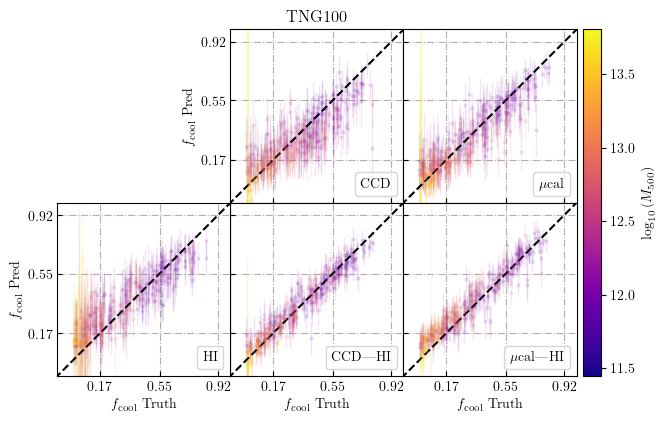

In [8]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "100"
grid1 = ["255","f_cool_R500c"]
grid2 = ["257","f_cool_R500c"]
grid3 = ["265","f_cool_R500c"]
grid4 = ["267","f_cool_R500c"]
grid5 = ["258","f_cool_R500c"]
choice_array = [grid1,grid2,grid3,grid4,grid5]
plot_array = []

fig = plt.figure(figsize=(6.7,4.5))
gs = fig.add_gridspec(2,3,hspace=0,wspace=0)
later_axis = plt.gca()
later_axis.set_axis_off()
axtitle = fig.add_subplot(gs[0,0])
axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[1,2])
ax5 = fig.add_subplot(gs[1,0])
# axtitle.annotate("TNG100", (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3,ax4,ax5]
cm = plt.get_cmap("plasma")
if(sim == "100"):
    Master = np.array([DO_100_new["f_cool_R500c"]])
elif(sim == "300"):
    Master = np.array([DO_new["f_cool_R500c"]])
maxs = np.max(Master)
mins = np.min(Master)
window_range = (maxs-mins)*0.25/2
for i,choice in enumerate(choice_array):
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
#     print("params = ",params)
#     print("choice = ",choice)
#     print("param_index = ",param_index)
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='plasma',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     print(mins,maxs,window_range,mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
#     ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
    ax.set_xticks(np.arange(0,1.5,0.5))
    ax.set_yticks(np.arange(0,1.5,0.5))
    ax.tick_params(direction='in')
#     if(sim=="300"):
#         ax.set_xticks(np.arange(12,15))
#     elif(sim=="100"):
#         ax.set_xticks(np.arange(12,15))
#     plt.tight_layout()
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelleft=False,labelbottom=False)
ax3.tick_params(labelleft=False)
ax4.tick_params(labelleft=False)

ax1.set_xlim(f_cool_TNG100_lim)
ax1.set_ylim(f_cool_TNG100_lim)
ax1.xaxis.set_ticks(f_cool_TNG100_ticks)
ax1.yaxis.set_ticks(f_cool_TNG100_ticks)

ax2.set_xlim(f_cool_TNG100_lim)
ax2.set_ylim(f_cool_TNG100_lim)
ax2.xaxis.set_ticks(f_cool_TNG100_ticks)
ax2.yaxis.set_ticks(f_cool_TNG100_ticks)

ax3.set_xlim(f_cool_TNG100_lim)
ax3.set_ylim(f_cool_TNG100_lim)
ax3.xaxis.set_ticks(f_cool_TNG100_ticks)
ax3.yaxis.set_ticks(f_cool_TNG100_ticks)

ax4.set_xlim(f_cool_TNG100_lim)
ax4.set_ylim(f_cool_TNG100_lim)
ax4.xaxis.set_ticks(f_cool_TNG100_ticks)
ax4.yaxis.set_ticks(f_cool_TNG100_ticks)

ax5.set_xlim(f_cool_TNG100_lim)
ax5.set_ylim(f_cool_TNG100_lim)
ax5.xaxis.set_ticks(f_cool_TNG100_ticks)
ax5.yaxis.set_ticks(f_cool_TNG100_ticks)
#### Add axis titles
ax1.set_ylabel(r"$f_{\rm cool}$ Pred")
ax5.set_ylabel(r"$f_{\rm cool}$ Pred")
ax5.set_xlabel(r"$f_{\rm cool}$ Truth")
ax3.set_xlabel(r"$f_{\rm cool}$ Truth")
ax4.set_xlabel(r"$f_{\rm cool}$ Truth")
ax1.title.set_text("TNG100")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.4,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig4.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### TNG300 M500c fig 5

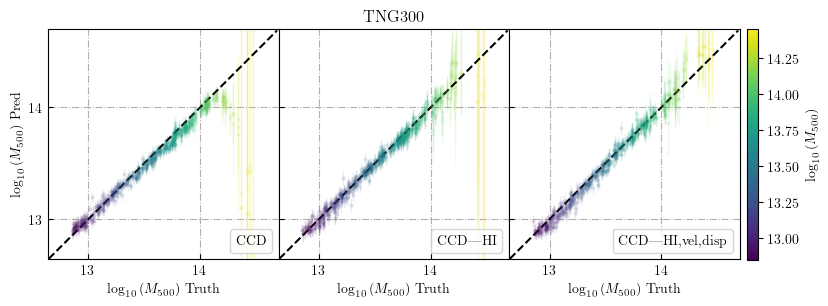

In [9]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "300"
grid1 = ["254","M500c"]
grid2 = ["264","M500c"]
grid3 = ["260","M500c"]
choice_array = [grid1,grid2,grid3]
plot_array = []

fig = plt.figure(figsize=(8.925,3))
gs = fig.add_gridspec(1,3,hspace=0,wspace=0)
later_axis = plt.gca()
later_axis.set_axis_off()
# axtitle = fig.add_subplot(gs[0,0])
# axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
# axtitle.annotate(r'$M_{500}$'+'\n'+r'$Pred\ Vs.\ Truth$', (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3]
cm = plt.get_cmap("viridis")
if(sim == "100"):
    Master = np.array([DO_100_new["M500c"]])
elif(sim == "300"):
    Master = np.array([DO_new["M500c"]])
maxs = np.max(Master)
mins = np.min(Master)
window_range = (maxs-mins)*0.25/2
for i,choice in enumerate(choice_array):
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='viridis',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
#     title = f"TNG{sim}|"
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xticks(np.arange(13,15)) ##  Change based on sim
    ax.set_yticks(np.arange(13,15))
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
#     plt.tight_layout()
    ax.tick_params(direction='in')
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
M500_TNG300_ticks = np.array([13,14])
M500_TNG300_lim = (12.64, 14.7)

ax1.set_xlim(M500_TNG300_lim)
ax1.set_ylim(M500_TNG300_lim)
ax1.xaxis.set_ticks(M500_TNG300_ticks)
ax1.yaxis.set_ticks(M500_TNG300_ticks)

ax2.set_xlim(M500_TNG300_lim)
ax2.set_ylim(M500_TNG300_lim)
ax2.xaxis.set_ticks(M500_TNG300_ticks)
ax2.yaxis.set_ticks(M500_TNG300_ticks)

ax3.set_xlim(M500_TNG300_lim)
ax3.set_ylim(M500_TNG300_lim)
ax3.xaxis.set_ticks(M500_TNG300_ticks)
ax3.yaxis.set_ticks(M500_TNG300_ticks)

ax2.tick_params(labelleft=False)
ax3.tick_params(labelleft=False)
#### Add axis titles
ax1.set_ylabel(r"$\log_{10}{(M_{500})}$ Pred")
ax1.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax2.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax3.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax2.title.set_text("TNG300")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.2,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig5.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### TNG300 f_gas fig 6

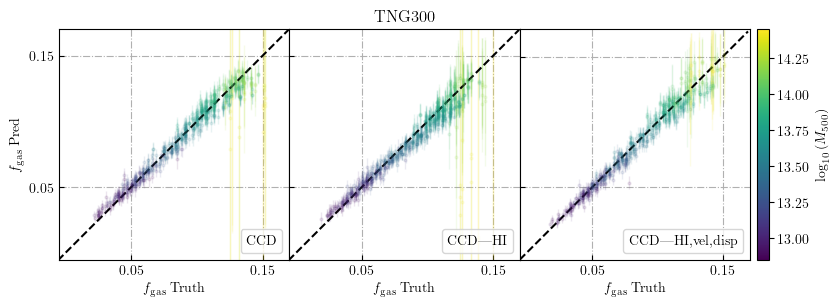

In [10]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "300"
grid1 = ["254","f_gas_R500c"]
grid2 = ["264","f_gas_R500c"]
grid3 = ["260","f_gas_R500c"]
choice_array = [grid1,grid2,grid3]
plot_array = []

fig = plt.figure(figsize=(8.925,3))
gs = fig.add_gridspec(1,3,hspace=0,wspace=0)
later_axis = plt.gca()
later_axis.set_axis_off()
# axtitle = fig.add_subplot(gs[0,0])
# axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
# axtitle.annotate(r'$M_{500}$'+'\n'+r'$Pred\ Vs.\ Truth$', (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3]
if(sim == "100"):
    Master = np.array([DO_100_new["f_gas_R500c"]])
    cm = plt.get_cmap("plasma")
elif(sim == "300"):
    Master = np.array([DO_new["f_gas_R500c"]])
    cm = plt.get_cmap("viridis")
maxs = np.max(Master)
mins = np.min(Master)
window_range = (maxs-mins)*0.25/2
for i,choice in enumerate(choice_array):
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='viridis',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
#     title = f"TNG{sim}|"
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xticks(np.arange(0.05,0.25,0.1)) ##  Change based on sim
    ax.set_yticks(np.arange(0.05,0.25,0.1))
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
#     plt.tight_layout()
    ax.tick_params(direction='in')
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels

ax1.set_xlim(f_gas_TNG300_lim)
ax1.set_ylim(f_gas_TNG300_lim)
ax1.xaxis.set_ticks(f_gas_TNG300_ticks)
ax1.yaxis.set_ticks(f_gas_TNG300_ticks)

ax2.set_xlim(f_gas_TNG300_lim)
ax2.set_ylim(f_gas_TNG300_lim)
ax2.xaxis.set_ticks(f_gas_TNG300_ticks)
ax2.yaxis.set_ticks(f_gas_TNG300_ticks)

ax2.set_xlim(f_gas_TNG300_lim)
ax2.set_ylim(f_gas_TNG300_lim)
ax2.xaxis.set_ticks(f_gas_TNG300_ticks)
ax2.yaxis.set_ticks(f_gas_TNG300_ticks)

ax2.tick_params(labelleft=False)
ax3.tick_params(labelleft=False)
#### Add axis titles
ax1.set_ylabel(r"$f_{\rm gas}$ Pred")
ax1.set_xlabel(r"$f_{\rm gas}$ Truth")
ax2.set_xlabel(r"$f_{\rm gas}$ Truth")
ax3.set_xlabel(r"$f_{\rm gas}$ Truth")
ax2.title.set_text("TNG300")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.2,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig6.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### H1 comparison (Fig 7)

/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)
/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)


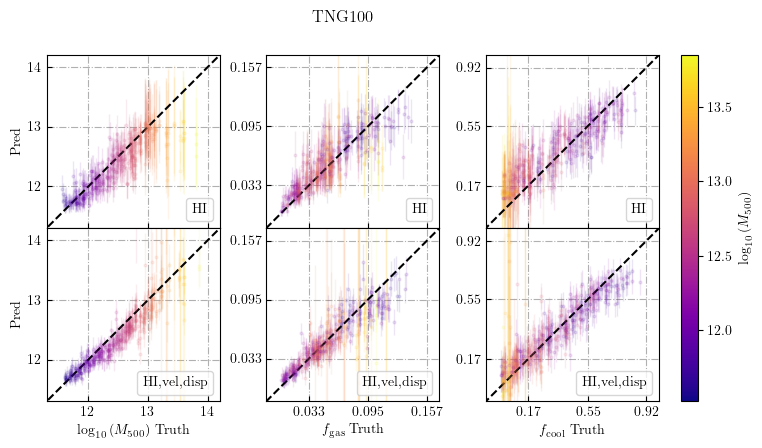

In [11]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "100"
grid1 = ["258","M500c"]
grid2 = ["258","f_gas_R500c"]
grid3 = ["258","f_cool_R500c"]
grid4 = ["259","M500c"]
grid5 = ["259","f_gas_R500c"]
grid6 = ["259","f_cool_R500c"]
choice_array = [grid1,grid2,grid3,grid4,grid5,grid6]
plot_array = []

fig = plt.figure(figsize=(8.5,4.5))
gs = fig.add_gridspec(2,3,hspace=0,wspace=0)
fig.suptitle("TNG100")
later_axis = plt.gca()
later_axis.set_axis_off()
# axtitle = fig.add_subplot(gs[0,0])
# axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,0])
ax5 = fig.add_subplot(gs[1,1])
ax6 = fig.add_subplot(gs[1,2])
# axtitle.annotate(r'$M_{500}$'+'\n'+r'$Pred\ Vs.\ Truth$', (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3,ax4,ax5,ax6]
for i,choice in enumerate(choice_array):
    if(sim == "100"):
        Master = np.array([DO_100_new[choice[1]]])
        cm = plt.get_cmap("plasma")
    elif(sim == "300"):
        Master = np.array([DO_new[choice[1]]])
        cm = plt.get_cmap("viridis")
    maxs = np.max(Master)
    mins = np.min(Master)
    window_range = (maxs-mins)/8
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='viridis',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
#     title = f"TNG{sim}|"
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xticks(np.arange(mins,maxs+(window_range*8/2),window_range*8/2)) ##  Change based on sim
    ax.set_yticks(np.arange(mins,maxs+(window_range*8/2),window_range*8/2))
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
#     plt.tight_layout()
    ax.tick_params(direction='in')
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)
ax3.tick_params(labelbottom=False)
#### x and y ticks
ax1.set_ylim(M500_TNG100_lim)
ax1.set_xlim(M500_TNG100_lim)
ax1.yaxis.set_ticks(M500_TNG100_ticks)
ax1.xaxis.set_ticks(M500_TNG100_ticks)

ax2.set_ylim(f_gas_TNG100_lim)
ax2.set_xlim(f_gas_TNG100_lim)
ax2.yaxis.set_ticks(f_gas_TNG100_ticks)
ax2.xaxis.set_ticks(f_gas_TNG100_ticks)

ax3.set_ylim(f_cool_TNG100_lim)
ax3.set_xlim(f_cool_TNG100_lim)
ax3.yaxis.set_ticks(f_cool_TNG100_ticks)
ax3.xaxis.set_ticks(f_cool_TNG100_ticks)

ax4.set_ylim(M500_TNG100_lim)
ax4.set_xlim(M500_TNG100_lim)
ax4.yaxis.set_ticks(M500_TNG100_ticks)
ax4.xaxis.set_ticks(M500_TNG100_ticks)

ax5.set_ylim(f_gas_TNG100_lim)
ax5.set_xlim(f_gas_TNG100_lim)
ax5.yaxis.set_ticks(f_gas_TNG100_ticks)
ax5.xaxis.set_ticks(f_gas_TNG100_ticks)

ax6.set_ylim(f_cool_TNG100_lim)
ax6.set_xlim(f_cool_TNG100_lim)
ax6.yaxis.set_ticks(f_cool_TNG100_ticks)
ax6.xaxis.set_ticks(f_cool_TNG100_ticks)
#### Add axis titles
ax4.set_xlabel(r"$\log_{10}{(M_{500})}$ Truth")
ax5.set_xlabel(r"$f_{\rm gas}$ Truth")
ax6.set_xlabel(r"$f_{\rm cool}$ Truth")
ax1.set_ylabel(r"Pred")
ax4.set_ylabel(r"Pred")
# ax1.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax2.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax3.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax1.title.set_text(r"$M_{500}$")
# ax2.title.set_text(r"$f_{\rm gas}$")
# ax3.title.set_text(r"$f_{\rm cool}$")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.2,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig7.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### Metallicity (Fig. 8)

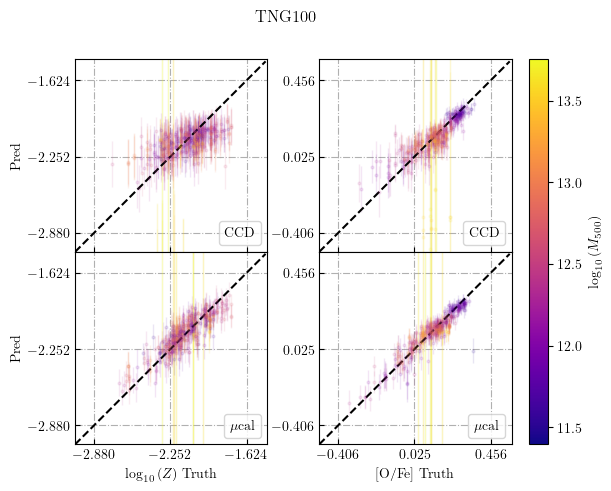

In [12]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "100"
grid1 = ["268","Log_Z_100"]
grid2 = ["268","OFe_100"]
grid3 = ["269","Log_Z_100"]
grid4 = ["269","OFe_100"]
choice_array = [grid1,grid2,grid3,grid4]
plot_array = []

fig = plt.figure(figsize=(6.3,5))
gs = fig.add_gridspec(2,2,hspace=0,wspace=0)
fig.suptitle("TNG100")
later_axis = plt.gca()
later_axis.set_axis_off()
# axtitle = fig.add_subplot(gs[0,0])
# axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
# axtitle.annotate(r'$M_{500}$'+'\n'+r'$Pred\ Vs.\ Truth$', (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3,ax4]
for i,choice in enumerate(choice_array):
    if(sim == "100"):
        Master = np.array([DO_100_new[choice[1]]])
        cm = plt.get_cmap("plasma")
    elif(sim == "300"):
        Master = np.array([DO_new[choice[1]]])
        cm = plt.get_cmap("viridis")
    maxs = np.max(Master)
    mins = np.min(Master)
    window_range = (maxs-mins)/8
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='viridis',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
#     title = f"TNG{sim}|"
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xticks(np.arange(mins,maxs+(window_range*8/2),window_range*8/2)) ##  Change based on sim
    ax.set_yticks(np.arange(mins,maxs+(window_range*8/2),window_range*8/2))
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
#     plt.tight_layout()
    ax.tick_params(direction='in')
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)
# ax3.tick_params(labelbottom=False)
#### Add axis titles
ax3.set_xlabel(r"$\log_{10}{(Z)}$ Truth")
ax3.set_ylabel(r"Pred")
ax1.set_ylabel(r"Pred")

ax4.set_xlabel(r"[O/Fe] Truth")
# ax4.set_ylabel(r"[O/Fe] Pred")
# ax2.set_ylabel(r"[O/Fe] Pred")
# ax1.set_ylabel(r"$f_{gas,R_{500}}$ Pred")
# ax1.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax2.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax3.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax1.title.set_text(r"$M_{500}$ Pred v Truth")
# ax2.title.set_text(r"$f_{gas,R_{500}}$ Pred v Truth")
# ax3.title.set_text(r"$f_{cool,R_{500}}$ Pred v Truth")
# ax1.title.set_text(r"$\log{Z}$")
# ax2.title.set_text("[O/Fe]")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.2,0.5),label=r"$\log_{10}{(M_{500})}$");
plt.savefig("fig8.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################

### TNG300 Metallicity

/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)
/projects/kaad8904/software/anaconda/envs/test/lib/python3.11/site-packages/permetrics/regression.py:296: RuntimeWarning: divide by zero encountered in divide
  result = np.mean(np.abs((y_pred - y_true) / y_true), axis=0)


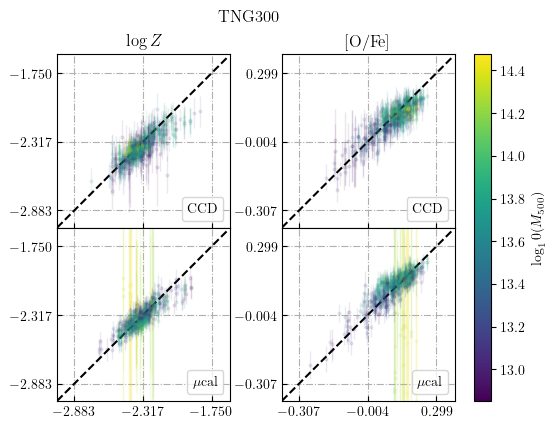

In [13]:
### Inputs:
tipe = "Loss"
legend = "Basic"
errorbar = "Y"
colorbar = "Y"
s_l_title = "N"
add_std = "N"
sim = "300"
grid1 = ["270","Log_Z"]
grid2 = ["270","OFe"]
grid3 = ["271","Log_Z"]
grid4 = ["271","OFe"]
choice_array = [grid1,grid2,grid3,grid4]
plot_array = []

fig = plt.figure(figsize=(5.8,4.5))
gs = fig.add_gridspec(2,2,hspace=0,wspace=0)
fig.suptitle("TNG300")
later_axis = plt.gca()
later_axis.set_axis_off()
# axtitle = fig.add_subplot(gs[0,0])
# axtitle.set_axis_off()
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
# axtitle.annotate(r'$M_{500}$'+'\n'+r'$Pred\ Vs.\ Truth$', (0, 0.5),
#                xycoords='axes fraction', va='center')
axis = [ax1,ax2,ax3,ax4]
for i,choice in enumerate(choice_array):
    if(sim == "100"):
        Master = np.array([DO_100_new[choice[1]]])
        cm = plt.get_cmap("plasma")
    elif(sim == "300"):
        Master = np.array([DO_new[choice[1]]])
        cm = plt.get_cmap("viridis")
    maxs = np.max(Master)
    mins = np.min(Master)
    window_range = (maxs-mins)/8
    index = -1
    channels = []
    trial_number = choice[0]
    params = []
    for j in range(len(output_array)):
        if(int(output_array[j][0]) == int(trial_number)):
            index = j

    if(index == -1):
        sys.exit('Trial Number not found, try again')
    else:
        date = output_array[index][1]
        num_channels = int(output_array[index][2])
        sim = output_array[index][3]
        for j in range(num_channels):
            channels.append(output_array[index][4+j])
        num_params = int(output_array[index][4+num_channels])
        for j in range(num_params):
            params.append(output_array[index][4+num_channels+1+j])

    data_dir = "/projects/kaad8904/CNN_Light/results/"
    results_dir = data_dir+"figures/"
    df = pd.read_csv(data_dir+"CNN_Light_Trial_"+trial_number+"_data_"+tipe+".csv")
    IDs = df["ID"]
    if(sim == "100"):
        Masses_100 = np.array([DO_100_new["M500c"][DO_100_new.index[DO_100_new["ID"]==j]] for j in IDs])
    elif(sim == "300"):
        Masses = np.array([DO_new["M500c"][DO_new.index[DO_new["ID"]==j]] for j in IDs])

    param_index = params.index(choice[1])
    ax = axis[i]

    x = df[df.keys()[3+param_index*3]].values
    y = df[df.keys()[1+param_index*3]].values
    y_err = df[df.keys()[2+param_index*3]].values

    if((legend == "Basic") | (legend == "basic")):
        RMSE = rmse(x, y)
        R2 = r2_score(x,y)
        RM_err = rel_mean_err(x,y)
        chi2 = chi_squared(x,y,y_err)

        RMSE = np.nanmean(RMSE)
        R2 = np.nanmean(R2)
        RM_err = np.nanmean(RM_err)
        chi2 = np.nanmean(chi2)

    elif((legend == "Binned") | (legend == "binned")):
        if(sim == "300"):
            mask1 = Masses < 13.35
            mask2 = Masses < 14.0
            labels = ["<13.35 bin","13.35 - 14.0 bin",">14.0 bin"]
        elif(sim == "100"):
            mask1 = Masses_100 < 12.3
            mask2 = Masses_100 < 13.0
            labels = ["<12.3 bin","12.3 - 13.0 bin",">13.0 bin"]
        x1 = x[mask1]
        y1 = y[mask1]
        y1_err = y_err[mask1]
        x2 = x[~mask1*mask2]
        y2 = y[~mask1*mask2]
        y2_err = y_err[~mask1*mask2]
        x3 = x[~mask2]
        y3 = y[~mask2]
        y3_err = y_err[~mask2]
        RMSE = [np.nanmean(rmse(x1,y1)),np.nanmean(rmse(x2,y2)),np.nanmean(rmse(x3,y3))]
        R2 = [np.nanmean(r2_score(x1,y1)),np.nanmean(r2_score(x2,y2)),np.nanmean(r2_score(x3,y3))]
        RM_err = [np.nanmean(rel_mean_err(x1,y1)),np.nanmean(rel_mean_err(x2,y2)),np.nanmean(rel_mean_err(x3,y3))]
        chi2 = [np.nanmean(chi_squared(x1,y1,np.exp(y1_err))),np.nanmean(chi_squared(x2,y2,np.exp(y2_err))),np.nanmean(chi_squared(x3,y3,np.exp(y3_err)))]

    if(sim == "300"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses[j],"300") != 0): continue
            if((errorbar == "Y") or (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))
            else: 
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                        c=cm((Masses[j]-np.min(Masses))/(np.max(Masses)-np.min(Masses))))

        dummydata = ax.scatter([np.min(Masses),np.max(Masses)],\
                               [np.min(Masses),np.max(Masses)],\
                               c=[np.min(Masses),np.max(Masses)], cmap='viridis',s=0.001)

    elif(sim == "100"):
        for j in range(len(x)):
            if(j%trim_mhalo_data(Masses_100[j],"100") != 0): continue
            if((errorbar == "Y") | (errorbar == "y")):
                ax.errorbar(x[j],y[j],np.exp(y_err[j]),linestyle='None', lw=1, fmt='o', ms=2, \
                        elinewidth=1, capsize=0, alpha=0.1, \
                        c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))
            else:
                ax.plot(x[j],y[j],linestyle="None",lw=1,marker='o',alpha=0.2,\
                       c=cm((Masses_100[j]-np.min(Masses_100))/(np.max(Masses_100)-np.min(Masses_100))))

        dummydata = ax.scatter([np.min(Masses_100),np.max(Masses_100)],\
                               [np.min(Masses_100),np.max(Masses_100)],\
                               c=[np.min(Masses_100),np.max(Masses_100)], cmap='plasma',s=0.001)

    ax.plot([mins-window_range,maxs+window_range],[mins-window_range,maxs+window_range],'k--')
#     if((colorbar == "Y") | (colorbar == 'y')):
#         div = axgrid.make_axes_locatable(ax)
#         cax = div.append_axes("right", size="5%", pad=0, zorder=20)
#         fig.colorbar(dummydata,cax=cax,label="Log(M500c)")

    ##########Title construction
#     title = f"TNG{sim}|"
    title = f""
    ccd = 0
    lem_wide = 0
    lem_narrow = 0
    H1 = 0
    for j in range(len(channels)):
        if(channels[j][-3:]=="ccd"):
            ccd+=1
        elif(channels[j][-3:]=="lem"):
            lem_wide+=1
        elif(channels[j][:2]=="H1"):
            H1+=1
        else:
            lem_narrow+=1

    if(ccd != 0):
        title = title+f"CCD|"
    if(lem_wide != 0):
        title = title+r"$\mu$cal|"
    if(H1==1):
        title = title+"HI|"
    if(H1==3):
        title = title+"HI,vel,disp|"
    if((s_l_title == "Y") | (s_l_title == 'y')):
        title = title+tipe+"|"
    title = title[:-1]
    ###############################
#     ax.set_title(title,y=0.85) # What the input is // Maybe make a key for letters so its not too long, or use all inputs
    ax.plot([],[],label=title,color='none',markerfacecolor='none')
    ax.set_xticks(np.arange(mins,maxs+(window_range*8/2),window_range*8/2)) ##  Change based on sim
    ax.set_yticks(np.arange(mins,maxs+(window_range*8/2),window_range*8/2))
    ax.set_xlim(mins-window_range,maxs+window_range*1.1)
    ax.set_ylim(mins-window_range,maxs+window_range*1.1)
#     ax.set_xlabel(params[param_index]+" Truth") # Truth of Property
#     ax.set_ylabel(params[param_index]+" Prediction") # Pred of Property
#     if((legend == "Basic") | (legend == "basic")):
#         ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err), color='none', markerfacecolor='none')
#         ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2), color='none', markerfacecolor='none')
#     elif((legend == "Binned") | (legend == "binned")):
#         for j in range(3):
#             ax.plot([],[],label=labels[j], color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\rm{RMSE}\ $'+ r'$ = {:.3f}$'.format(RMSE[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$R^2\ $'+ r'$ = {:.3f}$'.format(R2[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\epsilon\ $'+ r'$ = {:.3f}$'.format(RM_err[j]), color='none', markerfacecolor='none')
#             ax.plot([],[],label=r'$\chi^2\ $'+ r'$ = {:.3f}$'.format(chi2[j]), color='none', markerfacecolor='none')
    if((add_std == "Y") | (add_std == "y")):
        std_dist = np.sum(np.abs(x-y)/np.exp(y_err))/len(x)
        std_perc = np.sum((np.abs(x-y)/np.exp(y_err))<=1)/len(x)
#         print(std_perc)
#         ax.plot([],[],label=f"Std average = {std_dist:.3f}",color='none',markerfacecolor='none')
#         ax.plot([],[],label=f"Std percentage = {std_perc*100:.3g}%",color='none',markerfacecolor='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right')
#     plt.show()
#     plt.subplots_adjust(left=0.1, bottom=0.1,top=0.9,right=0.85)
#     ax.set_aspect(1.0/ax.get_data_ratio(),adjustable='box');
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-.')
#     plt.tight_layout()
    ax.tick_params(direction='in')
    file_name = results_dir+"Trial_"+str(trial_number)+"_"+params[param_index]+"_"+tipe+"_TvP"
    if((colorbar == "Y") | (colorbar == "y")):
        file_name = file_name+"_color"
    if(legend == "Binned"):
        file_name = file_name+"_binned"
    if((errorbar == "Y") | (errorbar == "y")):
        file_name = file_name+"_errbar"
    else:
        file_name = file_name+"_nerrbar"
#### remove mid-labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)
# ax3.tick_params(labelbottom=False)
#### Add axis titles
# ax1.set_ylabel(r"$f_{gas,R_{500}}$ Pred")
# ax1.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax2.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax3.set_xlabel(r"$f_{gas,R_{500}}$ Truth",rotation=45)
# ax1.title.set_text(r"$M_{500}$ Pred v Truth")
# ax2.title.set_text(r"$f_{gas,R_{500}}$ Pred v Truth")
# ax3.title.set_text(r"$f_{cool,R_{500}}$ Pred v Truth")
ax1.title.set_text(r"$\log{Z}$")
ax2.title.set_text("[O/Fe]")
fig.colorbar(dummydata,ax=later_axis,anchor=(1.2,0.5),label=r"$\log_10{(M_{500})}$");
plt.savefig("fig9.png",bbox_inches='tight',dpi=300) ########### CHANGE WITH EACH FIGURE ###################